In [ ]:
'''Problem Statement

A financial research company wants to analyze historical NIFTY 50 market data to understand:

Overall market trend
Price movement
Trading volume behavior
Market volatility
Best and worst trading periods
Business insights for investors

The goal is to convert raw market data into meaningful business insights using Data Analytics.'''

In [ ]:
'''Project Objectives
Understand historical market performance.
Clean and preprocess stock market data.
Perform Exploratory Data Analysis (EDA).
Create meaningful business KPIs.
Visualize trends and patterns.
Generate business insights for investment decisions.'''

In [ ]:
#part 1 ========================================
# Import Libraries
# ========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [ ]:
df=pd.read_csv('/content/NIFTY50.csv')

In [ ]:
df

,Date,Adj Close,Close,High,Low,Open,Volume
0,04-01-2010,5232.200195,5232.200195,5238.450195,5167.100098,5200.899902,0
1,05-01-2010,5277.899902,5277.899902,5288.350098,5242.399902,5277.149902,0
2,06-01-2010,5281.799805,5281.799805,5310.850098,5260.049805,5278.149902,0
3,07-01-2010,5263.100098,5263.100098,5302.549805,5244.750000,5281.799805,0
4,08-01-2010,5244.750000,5244.750000,5276.750000,5234.700195,5264.250000,0
...,...,...,...,...,...,...,...
3924,24-12-2025,26142.099610,26142.099610,26236.400390,26123.000000,26170.650390,188800
3925,26-12-2025,26042.300780,26042.300780,26144.199220,26008.599610,26121.250000,142200
3926,29-12-2025,25942.099610,25942.099610,26106.800780,25920.300780,26063.349610,234300
3927,30-12-2025,25938.849610,25938.849610,25976.750000,25878.000000,25940.900390,396900


In [ ]:
df.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,04-01-2010,5232.200195,5232.200195,5238.450195,5167.100098,5200.899902,0
1,05-01-2010,5277.899902,5277.899902,5288.350098,5242.399902,5277.149902,0
2,06-01-2010,5281.799805,5281.799805,5310.850098,5260.049805,5278.149902,0
3,07-01-2010,5263.100098,5263.100098,5302.549805,5244.750000,5281.799805,0
4,08-01-2010,5244.750000,5244.750000,5276.750000,5234.700195,5264.250000,0


In [ ]:
#Dataset Shape
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 3929
Columns : 11


In [ ]:
#Column Names
df.columns

Index(['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [ ]:
#Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3929 entries, 0 to 3928
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       3929 non-null   object 
 1   Adj Close  3929 non-null   float64
 2   Close      3929 non-null   float64
 3   High       3929 non-null   float64
 4   Low        3929 non-null   float64
 5   Open       3929 non-null   float64
 6   Volume     3929 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 215.0+ KB


In [ ]:
#Statistical Summary
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,3929,2018-01-07 10:01:04.138457600,2010-01-04 00:00:00,2014-01-03 00:00:00,2018-01-11 00:00:00,2022-01-10 00:00:00,2025-12-31 00:00:00,NaN
Adj Close,3929.0,11838.522035,4544.200195,6215.149902,10113.7002,16983.55078,26216.05078,6230.830736
Close,3929.0,11838.522035,4544.200195,6215.149902,10113.7002,16983.55078,26216.05078,6230.830736
High,3929.0,11902.17157,4623.149902,6252.450195,10155.65039,17112.34961,26325.80078,6254.343683
Low,3929.0,11772.375382,4531.149902,6179.5,10049.09961,16850.15039,26172.40039,6205.229697
Open,3929.0,11845.503399,4623.149902,6205.700195,10101.0498,17009.05078,26325.80078,6232.051056
Volume,3929.0,240927.05523,0.0,131700.0,213500.0,312100.0,1811000.0,202269.286422
Year,3929.0,2017.519471,2010.0,2014.0,2018.0,2022.0,2025.0,4.616691
Quarter,3929.0,2.503945,1.0,2.0,3.0,3.0,4.0,1.113492


In [ ]:
#Missing Values
df.isnull().sum()

,0
Date,0
Adj Close,0
Close,0
High,0
Low,0
Open,0
Volume,0


In [ ]:
#Duplicate Records
df.duplicated().sum()

np.int64(0)

In [ ]:
#Remove Duplicates
df = df.drop_duplicates()

print("Duplicates Removed")

Duplicates Removed


In [ ]:
#Convert Date
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

In [ ]:
#Check Datatype Again
df.dtypes

,0
Date,datetime64[ns]
Adj Close,float64
Close,float64
High,float64
Low,float64
Open,float64
Volume,int64


In [ ]:
#Sort Dataset
df = df.sort_values("Date")

In [ ]:
#Reset Index
df.reset_index(drop=True, inplace=True)

In [ ]:
#Final Dataset Preview
df.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,2010-01-04,5232.200195,5232.200195,5238.450195,5167.100098,5200.899902,0
1,2010-01-05,5277.899902,5277.899902,5288.350098,5242.399902,5277.149902,0
2,2010-01-06,5281.799805,5281.799805,5310.850098,5260.049805,5278.149902,0
3,2010-01-07,5263.100098,5263.100098,5302.549805,5244.750000,5281.799805,0
4,2010-01-08,5244.750000,5244.750000,5276.750000,5234.700195,5264.250000,0


In [ ]:
#Create Year
df["Year"] = df["Date"].dt.year

In [ ]:
#Create Month
df["Month"] = df["Date"].dt.month_name()

In [ ]:
#Quarter
df["Quarter"] = df["Date"].dt.quarter

In [ ]:
#Weekday
df["Weekday"] = df["Date"].dt.day_name()

In [ ]:
#Check New Dataset
df.head()

,Date,Adj Close,Close,High,Low,Open,Volume,Year,Month,Quarter,Weekday
0,2010-01-04,5232.200195,5232.200195,5238.450195,5167.100098,5200.899902,0,2010,January,1,Monday
1,2010-01-05,5277.899902,5277.899902,5288.350098,5242.399902,5277.149902,0,2010,January,1,Tuesday
2,2010-01-06,5281.799805,5281.799805,5310.850098,5260.049805,5278.149902,0,2010,January,1,Wednesday
3,2010-01-07,5263.100098,5263.100098,5302.549805,5244.750000,5281.799805,0,2010,January,1,Thursday
4,2010-01-08,5244.750000,5244.750000,5276.750000,5234.700195,5264.250000,0,2010,January,1,Friday


In [ ]:
import os

#Save Clean Dataset
if not os.path.exists('data'):
    os.makedirs('data')
df.to_csv('data/NIFTY50_Cleaned.csv', index=False)

In [ ]:
#Initial EDA
#Number of Trading Days Per Year
df["Year"].value_counts().sort_index()

,count
Year,
2010,250
2011,242
2012,242
2013,247
2014,240
2015,244
2016,244
2017,248
2018,245


In [ ]:
#Number of Trading Days Per Month
df["Month"].value_counts()

,count
Month,
July,349
December,340
May,338
June,338
January,334
August,330
September,329
March,324
October,318


In [ ]:
#rading Days by Quarter
df["Quarter"].value_counts()

,count
Quarter,
3,1008
2,977
1,972
4,972


In [ ]:
#Trading Days by Weekday
df["Weekday"].value_counts()

,count
Weekday,
Tuesday,793
Monday,787
Thursday,787
Wednesday,785
Friday,776
Saturday,1


In [ ]:
"""Business Insights (Part 1)
Dataset contains approximately 16 years of historical NIFTY 50 trading data.
Date column has been converted into datetime format for time-series analysis.
Additional calendar features (Year, Month, Quarter, Weekday) have been created for business analysis.
Duplicate records have been removed.
The cleaned dataset has been saved for further analysis.'''

In [ ]:
'''In Part 2, we will build Feature Engineering similar to your Supply Chain project, including:

Daily Return
Price Change
Daily Range
High-Low %
Open-Close %
20-Day Moving Average
50-Day Moving Average
Volatility
Cumulative Return

Along with 10–15 business KPIs and deeper statistical analysis.'''

In [ ]:
#Part 2 – Feature Engineering & Business KPIs

In [ ]:

# Daily Price Change
df["Price Change"] = df["Close"] - df["Open"]

df.head()

,Date,Adj Close,Close,High,Low,Open,Volume,Year,Month,Quarter,Weekday,Price Change
0,2010-01-04,5232.200195,5232.200195,5238.450195,5167.100098,5200.899902,0,2010,January,1,Monday,31.300293
1,2010-01-05,5277.899902,5277.899902,5288.350098,5242.399902,5277.149902,0,2010,January,1,Tuesday,0.750000
2,2010-01-06,5281.799805,5281.799805,5310.850098,5260.049805,5278.149902,0,2010,January,1,Wednesday,3.649903
3,2010-01-07,5263.100098,5263.100098,5302.549805,5244.750000,5281.799805,0,2010,January,1,Thursday,-18.699707
4,2010-01-08,5244.750000,5244.750000,5276.750000,5234.700195,5264.250000,0,2010,January,1,Friday,-19.500000


In [ ]:
#Daily Return (%)
# Daily Return Percentage

df["Daily Return (%)"] = ((df["Close"]-df["Open"])/df["Open"])*100

df.head()

,Date,Adj Close,Close,High,Low,Open,Volume,Year,Month,Quarter,Weekday,Price Change,Daily Return (%)
0,2010-01-04,5232.200195,5232.200195,5238.450195,5167.100098,5200.899902,0,2010,January,1,Monday,31.300293,0.601825
1,2010-01-05,5277.899902,5277.899902,5288.350098,5242.399902,5277.149902,0,2010,January,1,Tuesday,0.750000,0.014212
2,2010-01-06,5281.799805,5281.799805,5310.850098,5260.049805,5278.149902,0,2010,January,1,Wednesday,3.649903,0.069151
3,2010-01-07,5263.100098,5263.100098,5302.549805,5244.750000,5281.799805,0,2010,January,1,Thursday,-18.699707,-0.354040
4,2010-01-08,5244.750000,5244.750000,5276.750000,5234.700195,5264.250000,0,2010,January,1,Friday,-19.500000,-0.370423


In [ ]:


# Daily Trading Range

df["Daily Range"] = df["High"]-df["Low"]

In [ ]:
#High-Low Percentage
df["High-Low (%)"] = ((df["High"]-df["Low"])/df["Low"])*100

In [ ]:
#Open-Close Percentage
df["Open-Close (%)"] = ((df["Close"]-df["Open"])/df["Open"])*100

In [ ]:
#20-Day Moving Average
#Business Use
#Short-term trend identify

df["20 Day MA"] = df["Close"].rolling(window=20).mean()



In [ ]:
#50-Day Moving Average
#Medium-term trend identify
df["50 Day MA"] = df["Close"].rolling(window=50).mean()




In [ ]:
#100-Day Moving Average
df["100 Day MA"] = df["Close"].rolling(window=100).mean()

In [ ]:
#Rolling Volatility
df["Volatility"] = df["Daily Return (%)"].rolling(20).std()

#Business Use

#Market risk measure

In [ ]:
#Previous Close
df["Previous Close"] = df["Close"].shift(1)

In [ ]:
#Gap Up / Gap Down
df["Gap"] = df["Open"] - df["Previous Close"]

In [ ]:
#Cumulative Return
df["Cumulative Return"]=(1+df["Daily Return (%)"]/100).cumprod()

In [ ]:
#Positive Trading Days
df["Profit Day"]=df["Price Change"]>0

In [ ]:
#Negative Trading Days
df["Loss Day"]=df["Price Change"]<0

In [ ]:
#Bullish Day
df["Bullish"]=df["Close"]>df["Open"]

In [ ]:
#Bullish Day
df["Bullish"]=df["Close"]>df["Open"]

In [ ]:
#Check Dataset
df.head()

,Date,Adj Close,Close,High,Low,Open,Volume,Year,Month,Quarter,...,20 Day MA,50 Day MA,100 Day MA,Volatility,Previous Close,Gap,Cumulative Return,Profit Day,Loss Day,Bullish
0,2010-01-04,5232.200195,5232.200195,5238.450195,5167.100098,5200.899902,0,2010,January,1,...,NaN,NaN,NaN,NaN,NaN,NaN,1.006018,True,False,True
1,2010-01-05,5277.899902,5277.899902,5288.350098,5242.399902,5277.149902,0,2010,January,1,...,NaN,NaN,NaN,NaN,5232.200195,44.949707,1.006161,True,False,True
2,2010-01-06,5281.799805,5281.799805,5310.850098,5260.049805,5278.149902,0,2010,January,1,...,NaN,NaN,NaN,NaN,5277.899902,0.250000,1.006857,True,False,True
3,2010-01-07,5263.100098,5263.100098,5302.549805,5244.750000,5281.799805,0,2010,January,1,...,NaN,NaN,NaN,NaN,5281.799805,0.000000,1.003292,False,True,False
4,2010-01-08,5244.750000,5244.750000,5276.750000,5234.700195,5264.250000,0,2010,January,1,...,NaN,NaN,NaN,NaN,5263.100098,1.149902,0.999576,False,True,False


In [ ]:
#Business KPIs

In [ ]:
#KPI 1
#Total Trading Days
print("Total Trading Days :",len(df))

Total Trading Days : 3929


In [ ]:
#KPI 2

#Highest Closing Price

print("Highest Close :",df["Close"].max())

Highest Close : 26216.05078


In [ ]:
#KPI 3

#Lowest Closing Price

print("Lowest Close :",df["Close"].min())


Lowest Close : 4544.200195


In [ ]:
#Average Closing Price

print("Average Close :",round(df["Close"].mean(),2))

Average Close : 11838.52


In [ ]:
#KPI 5

#Highest Opening Price

print("Highest Open :",df["Open"].max())

Highest Open : 26325.80078


In [ ]:
#KPI 6

#Lowest Opening Price

print("Lowest Open :",df["Open"].min())

Lowest Open : 4623.149902


In [ ]:
#KPI 7

#Highest Volume

print("Highest Volume :",df["Volume"].max())

Highest Volume : 1811000


In [ ]:
#KPI 8

#Average Volume

print("Average Volume :",round(df["Volume"].mean(),2))

Average Volume : 240927.06


In [ ]:
#KPI 9

#Highest Daily Gain

print("Highest Gain :",round(df["Daily Return (%)"].max(),2),"%")

Highest Gain : 9.31 %


In [ ]:
#KPI 10

#Highest Daily Loss

print("Highest Loss :",round(df["Daily Return (%)"].min(),2),"%")

Highest Loss : -6.82 %


In [ ]:
#KPI 11

#Average Daily Return

print("Average Return :",round(df["Daily Return (%)"].mean(),2),"%")

Average Return : -0.06 %


In [ ]:
#KPI 12

#Average Daily Range

print("Average Daily Range :",round(df["Daily Range"].mean(),2))

Average Daily Range : 129.8


In [ ]:
#KPI 13

#Average Volatility

print("Average Volatility :",round(df["Volatility"].mean(),2))

Average Volatility : 0.8


In [ ]:
#KPI 14

#Profit Days

print("Profit Days :",df["Profit Day"].sum())

Profit Days : 1847


In [ ]:
#KPI 15

#Loss Days

print("Loss Days :",df["Loss Day"].sum())

Loss Days : 2081


In [ ]:
#KPI 16

#Bullish Days

print("Bullish Days :",df["Bullish"].sum())

Bullish Days : 1847


In [ ]:
#KPI 17
#Bearish Days
df["Bearish"] = df["Close"] < df["Open"]
print("Bearish Days :",df["Bearish"].sum())

Bearish Days : 2081


In [ ]:
#ave Feature Engineered Dataset
df.to_csv("data/NIFTY50_Feature_Engineered.csv",index=False)

In [ ]:
'''Business Insights

After this stage, we can answer:

How many trading days occurred?
When did the biggest daily gain happen?
When did the biggest daily loss happen?
What is the average return?
What is the average volatility?
How many bullish and bearish days were there?
What was the average trading range of the market?
How are moving averages behaving in terms of the long-term trend?'''

In [ ]:
#Part 3 – Data Visualization & Business Insights

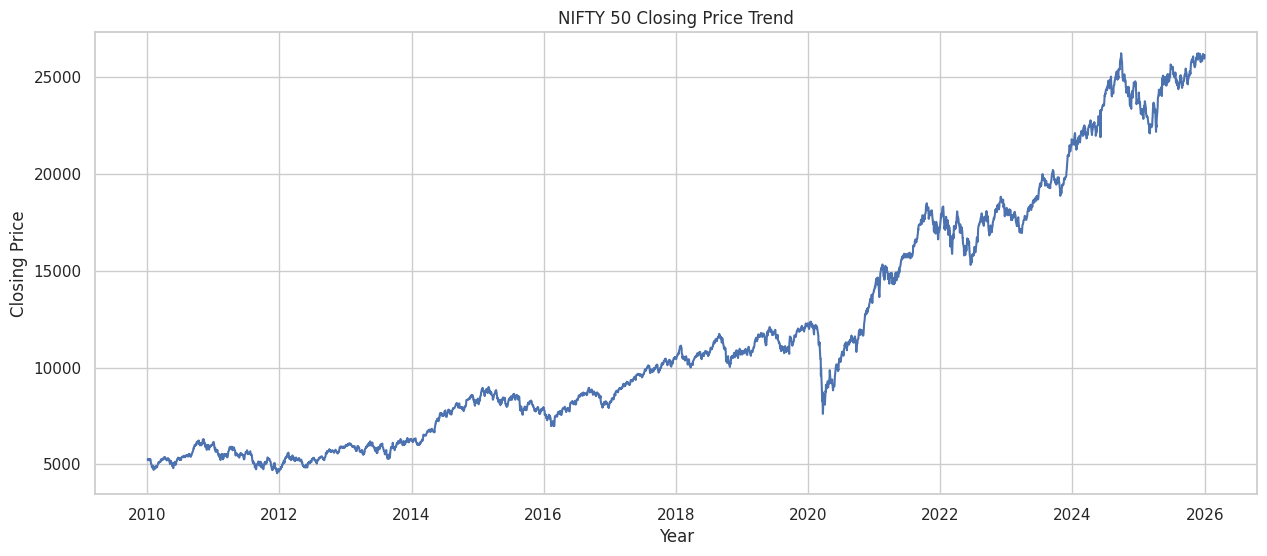

In [ ]:
#Visualization 1 – Closing Price Trend
plt.figure(figsize=(15,6))

plt.plot(df["Date"],df["Close"])

plt.title("NIFTY 50 Closing Price Trend")

plt.xlabel("Year")

plt.ylabel("Closing Price")

plt.show()

In [ ]:
#Business Insight

''''The market shows a long-term upward trend.
Temporary corrections are also observed.'''

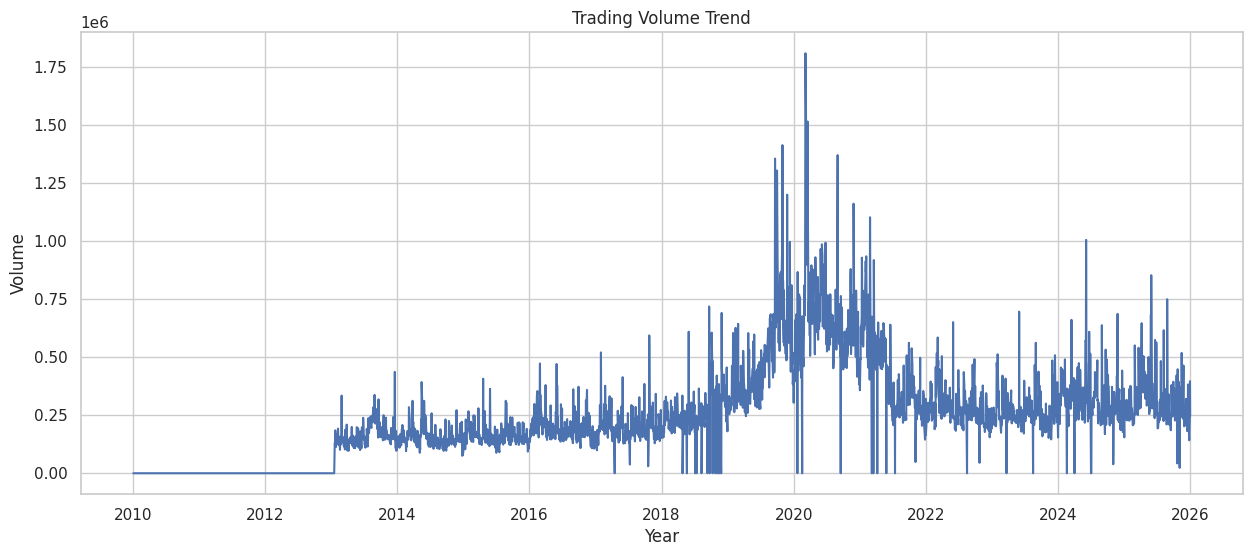

In [ ]:
#Visualization 2 – Trading Volume Trend
plt.figure(figsize=(15,6))

plt.plot(df["Date"],df["Volume"])

plt.title("Trading Volume Trend")

plt.xlabel("Year")

plt.ylabel("Volume")

plt.show()

In [ ]:
#Business Insight
#High volume days major market events indicate

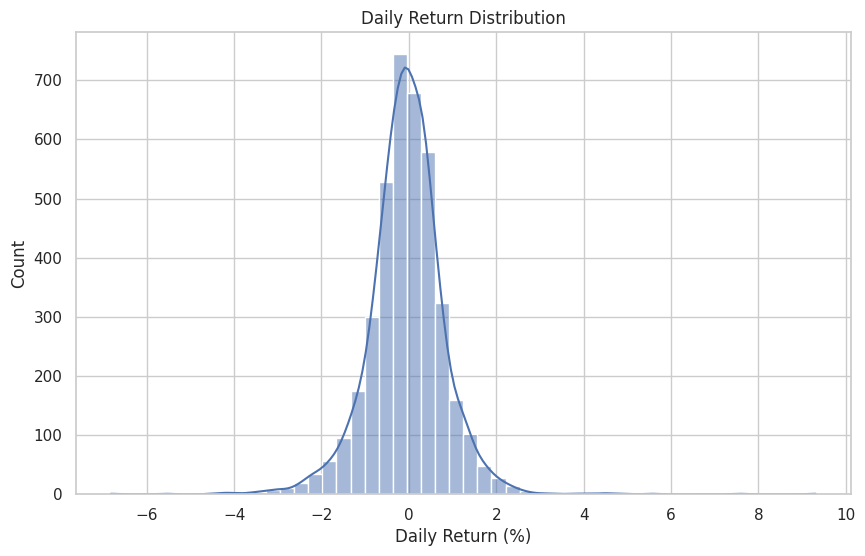

'Business Insight\nMost daily returns 0% around clustered.\nExtreme gains/losses occur.'

In [ ]:
#Visualization 3 – Daily Return Distribution
plt.figure(figsize=(10,6))

sns.histplot(df["Daily Return (%)"],bins=50,kde=True)

plt.title("Daily Return Distribution")

plt.show()
'''Business Insight
Most daily returns 0% around clustered.
Extreme gains/losses occur.'''

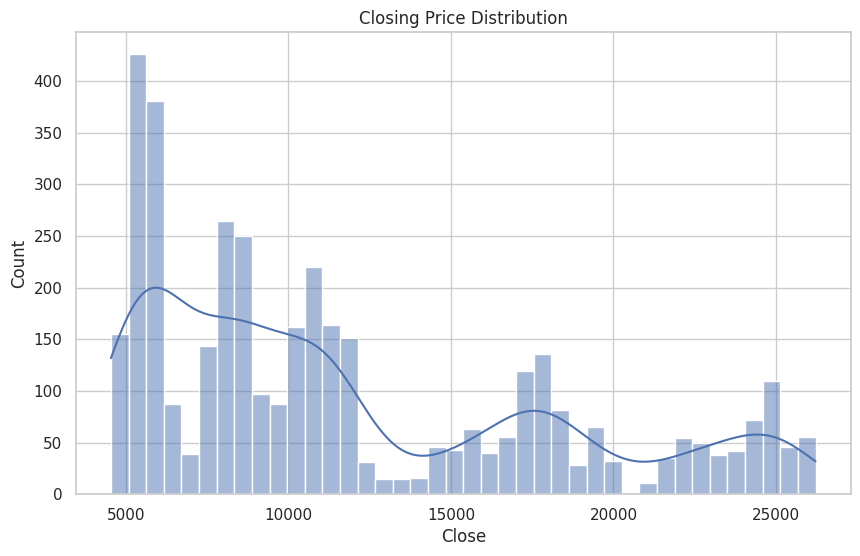

In [ ]:
#Visualization 4 – Closing Price Distribution
plt.figure(figsize=(10,6))

sns.histplot(df["Close"],bins=40,kde=True)

plt.title("Closing Price Distribution")

plt.show()

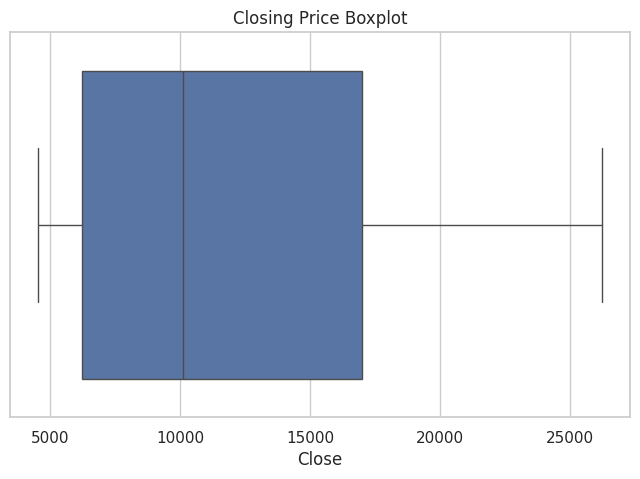

'Business Insight\nOutliers major bull runs ko represent kar sakte hain.'

In [ ]:
#Visualization 5 – Closing Price Boxplot
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Close"])

plt.title("Closing Price Boxplot")

plt.show()
'''Business Insight
Outliers major bull runs may represent'''

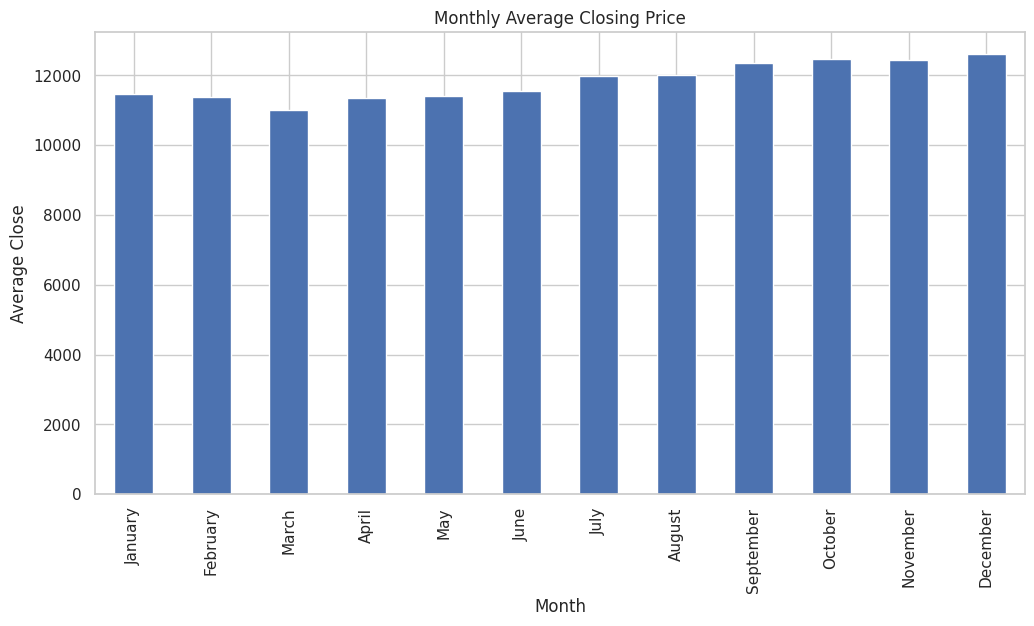

In [ ]:
#Visualization 6 – Monthly Average Closing Price
monthly=df.groupby("Month")["Close"].mean()

plt.figure(figsize=(12,6))

monthly.reindex([
"January","February","March","April","May","June",
"July","August","September","October","November","December"
]).plot(kind="bar")

plt.title("Monthly Average Closing Price")

plt.ylabel("Average Close")

plt.show()

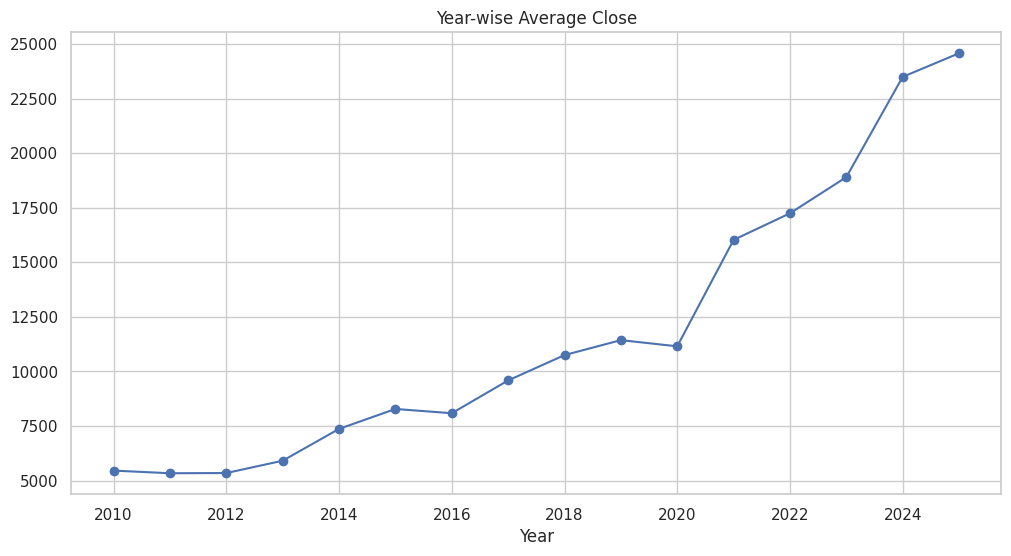

In [ ]:
#Visualization 7 – Year-wise Average Closing Price
year=df.groupby("Year")["Close"].mean()

plt.figure(figsize=(12,6))

year.plot(marker="o")

plt.title("Year-wise Average Close")

plt.show()

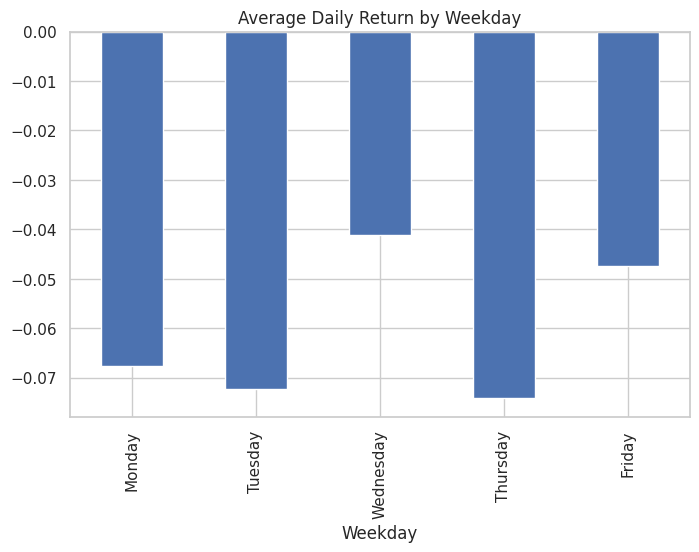

'Business Insight\nIdentify which weekday performs best on average'

In [ ]:
#Visualization 8 – Weekday Performance
weekday=df.groupby("Weekday")["Daily Return (%)"].mean()

weekday=weekday.reindex([
"Monday",
"Tuesday",
"Wednesday",
"Thursday",
"Friday"
])

plt.figure(figsize=(8,5))

weekday.plot(kind="bar")

plt.title("Average Daily Return by Weekday")

plt.show()
'''Business Insight
Identify which weekday performs best on average'''

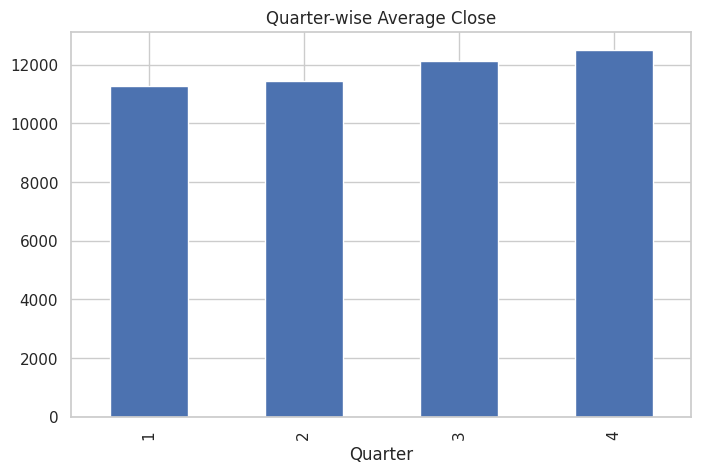

In [ ]:
#Visualization 9 – Quarterly Performance
quarter=df.groupby("Quarter")["Close"].mean()

plt.figure(figsize=(8,5))

quarter.plot(kind="bar")

plt.title("Quarter-wise Average Close")

plt.show()

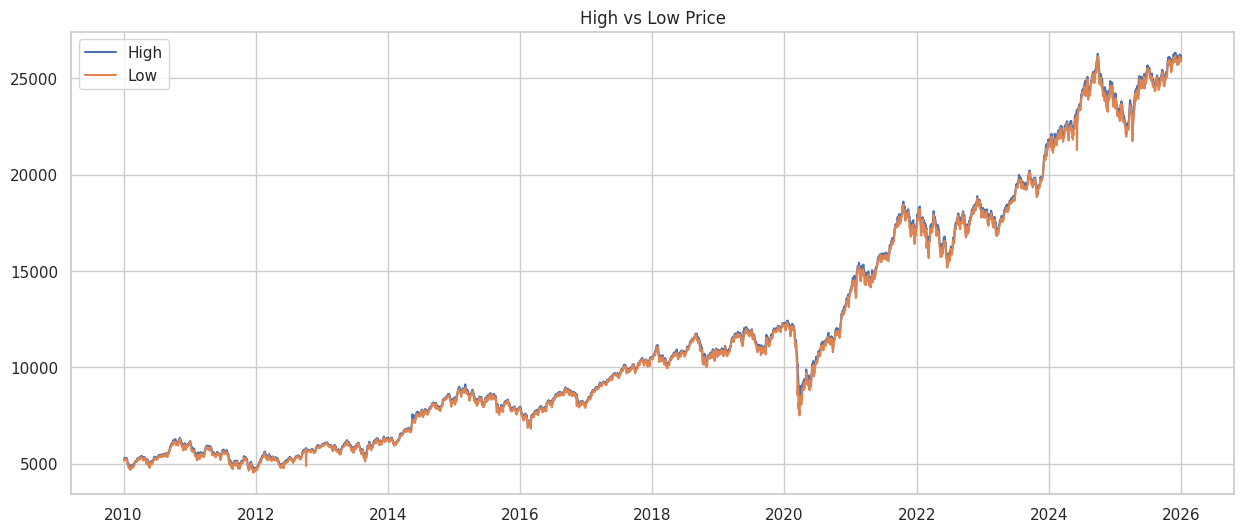

In [ ]:
#Visualization 10 – High vs Low Price
plt.figure(figsize=(15,6))

plt.plot(df["Date"],df["High"],label="High")

plt.plot(df["Date"],df["Low"],label="Low")

plt.legend()

plt.title("High vs Low Price")

plt.show()

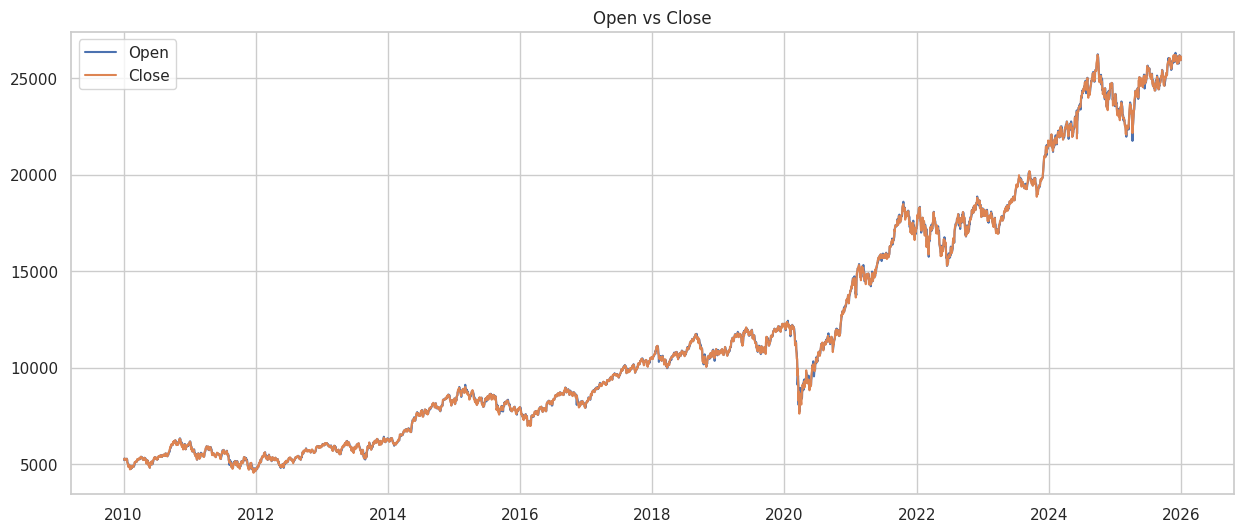

In [ ]:
#Visualization 11 – Open vs Close
plt.figure(figsize=(15,6))

plt.plot(df["Date"],df["Open"],label="Open")

plt.plot(df["Date"],df["Close"],label="Close")

plt.legend()

plt.title("Open vs Close")

plt.show()

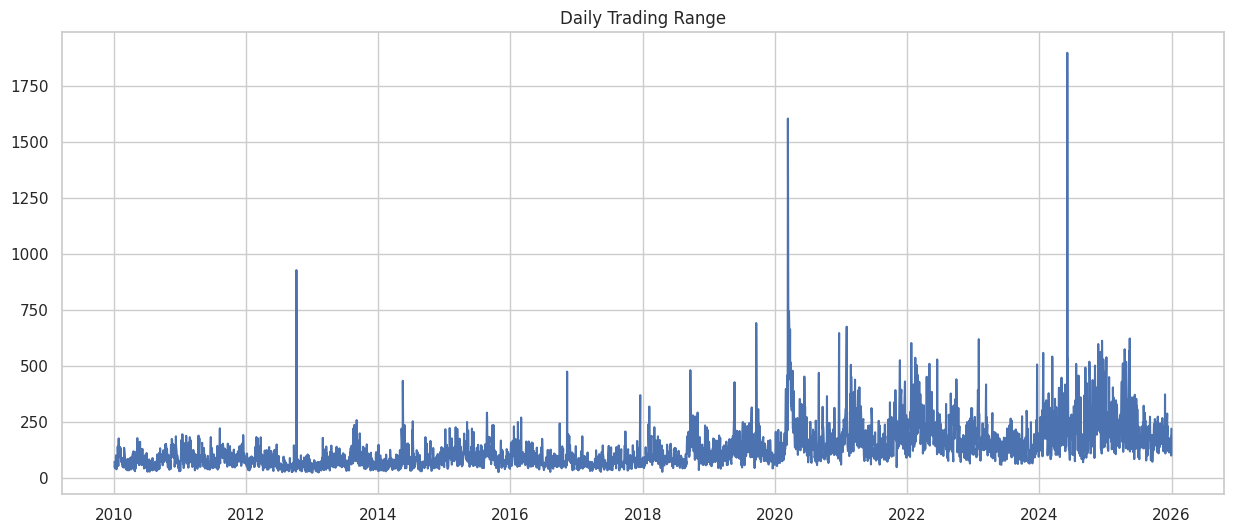

In [ ]:
#Visualization 12 – Daily Trading Range
plt.figure(figsize=(15,6))

plt.plot(df["Date"],df["Daily Range"])

plt.title("Daily Trading Range")

plt.show()

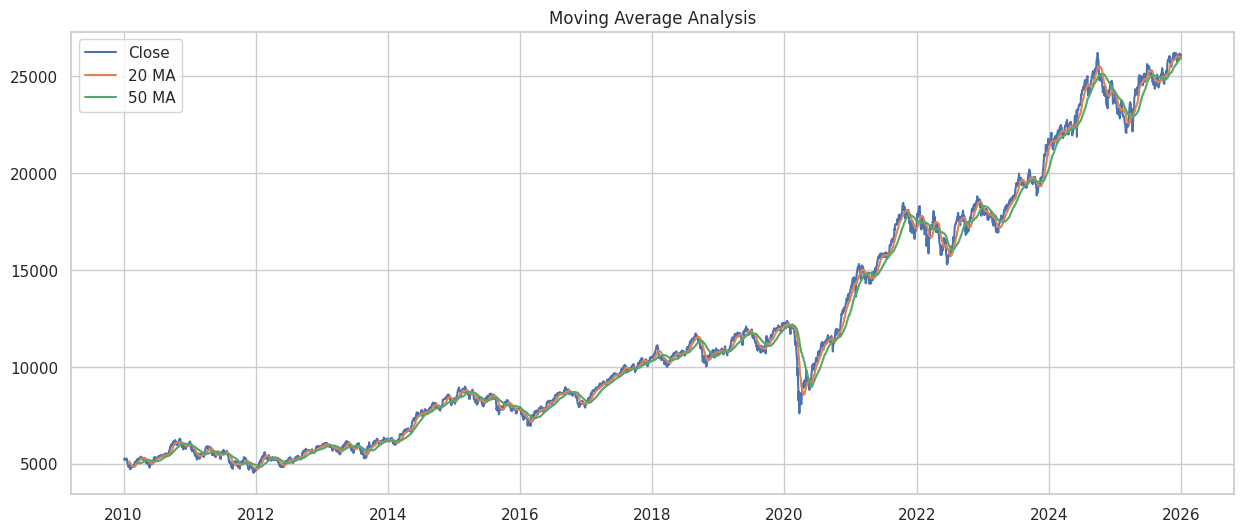

'Business Insight\nShort-term aur medium-term trend comparision '

In [ ]:
#Visualization 13 – Moving Average Analysis
plt.figure(figsize=(15,6))

plt.plot(df["Date"],df["Close"],label="Close")

plt.plot(df["Date"],df["20 Day MA"],label="20 MA")

plt.plot(df["Date"],df["50 Day MA"],label="50 MA")

plt.legend()

plt.title("Moving Average Analysis")

plt.show()
'''Business Insight
Short-term aur medium-term trend comparision '''

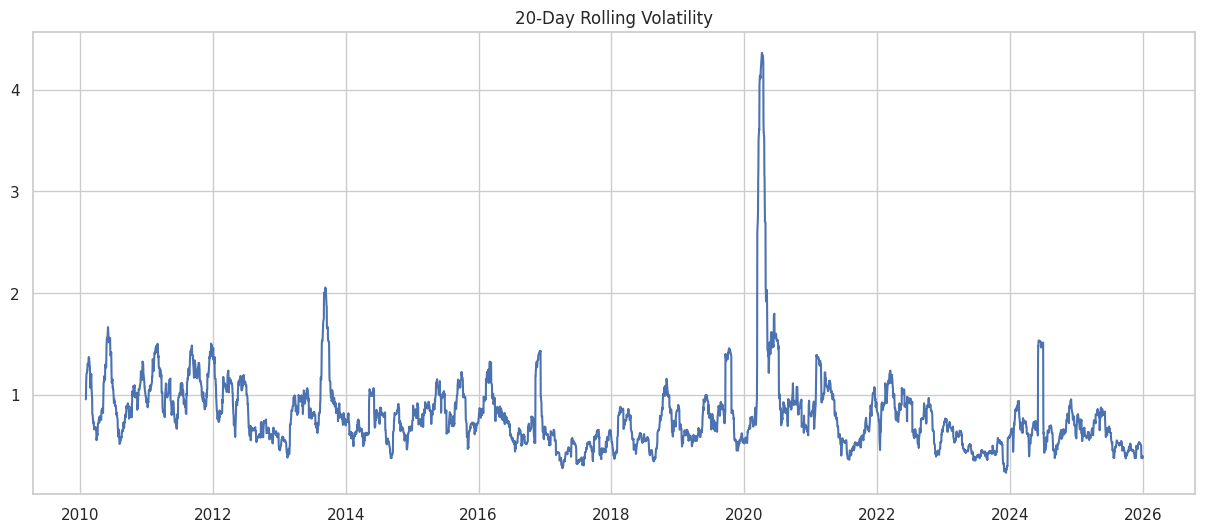

In [ ]:
#Visualization 14 – Volatility Trend
plt.figure(figsize=(15,6))

plt.plot(df["Date"],df["Volatility"])

plt.title("20-Day Rolling Volatility")

plt.show()

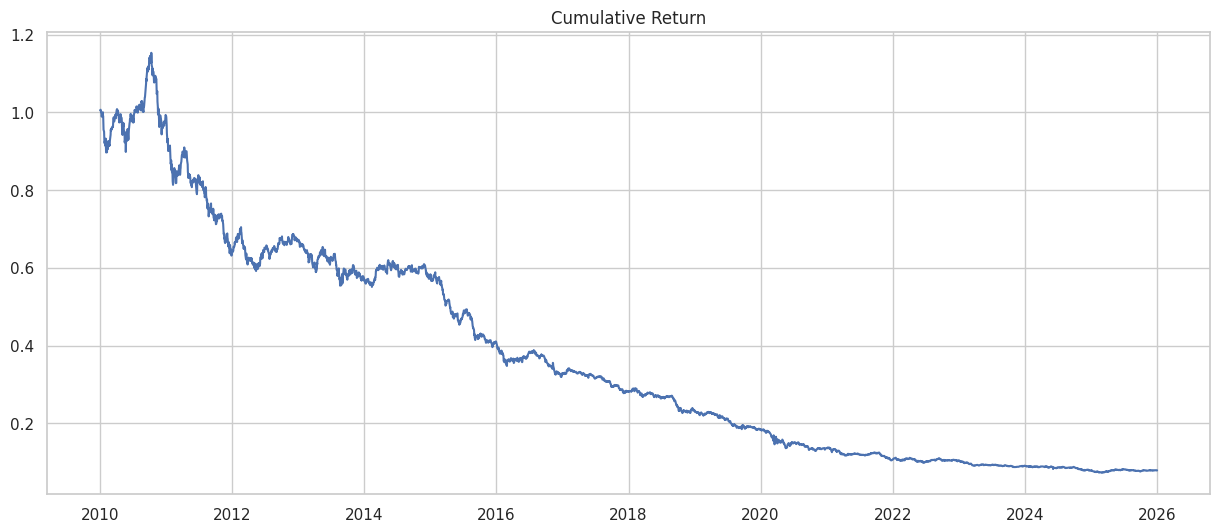

In [ ]:
#Visualization 15 – Cumulative Return
plt.figure(figsize=(15,6))

plt.plot(df["Date"],df["Cumulative Return"])

plt.title("Cumulative Return")

plt.show()

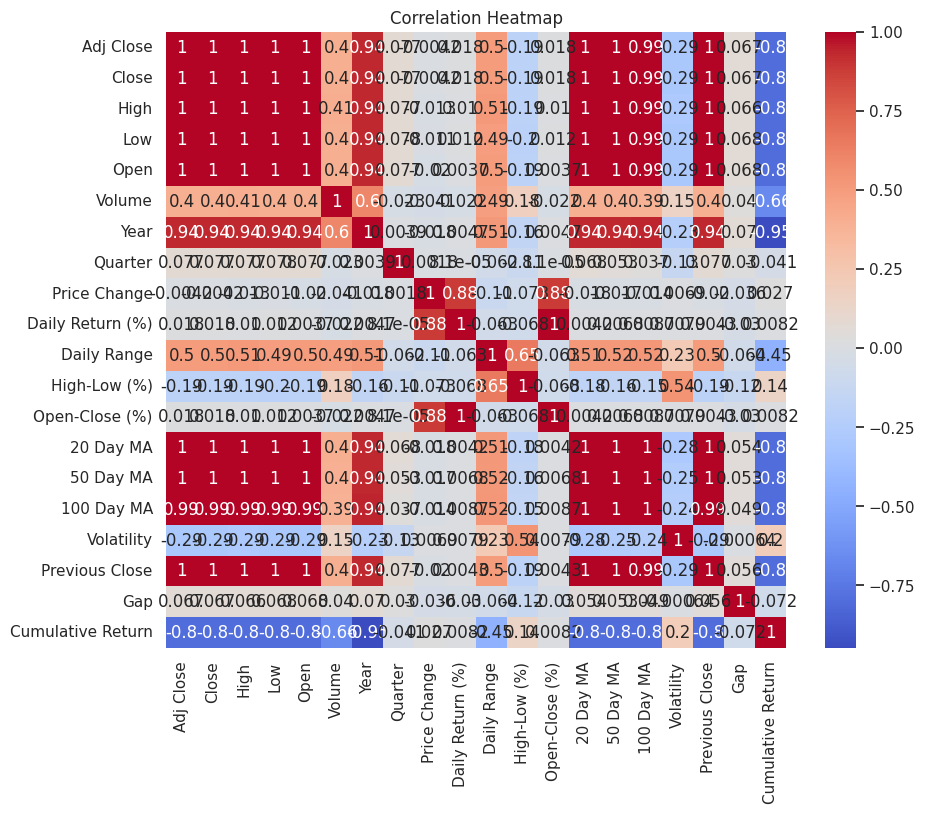

'Business Insight\nPrice columns generally highly correlated hote hain.\nVolume ka relationship alag observe ho sakta hai.'

In [ ]:
#Visualization 16 – Correlation Heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
df.select_dtypes(include="number").corr(),
annot=True,
cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()
'''Business Insight
Price columns generally highly correlated hote hain.
Volume ka relationship alag observe ho sakta hai.'''

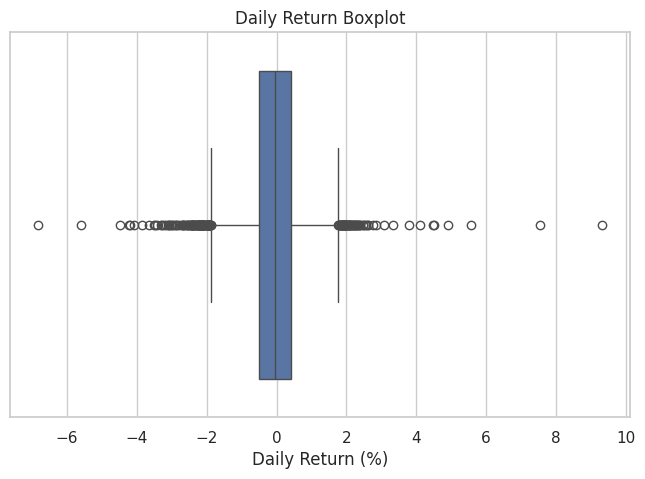

In [ ]:
#Visualization 17 – Return Boxplot
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Daily Return (%)"])

plt.title("Daily Return Boxplot")

plt.show()

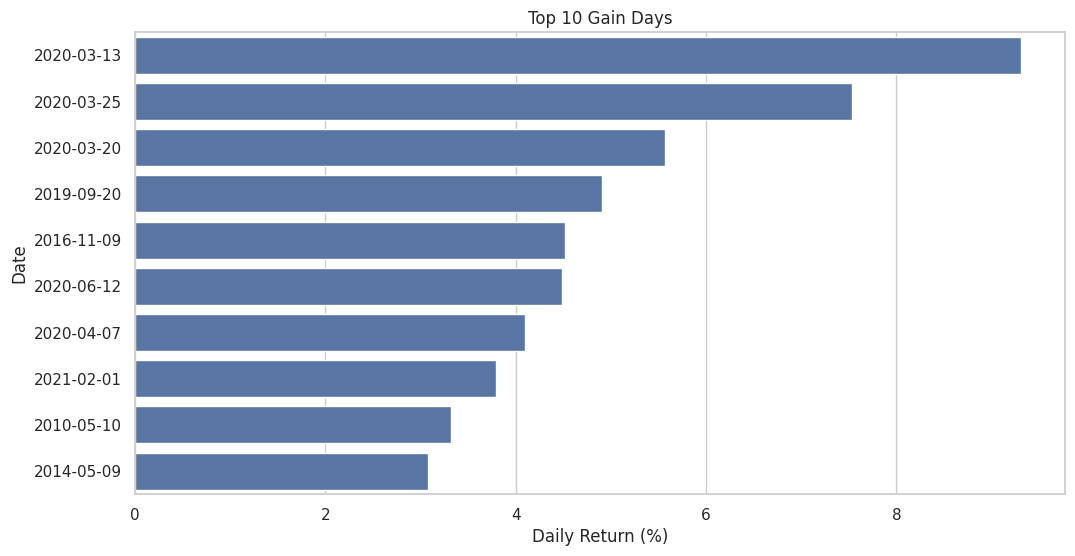

In [ ]:
#Visualization 18 – Top 10 Highest Gain Days
top_gain=df.nlargest(10,"Daily Return (%)")

plt.figure(figsize=(12,6))

sns.barplot(
data=top_gain,
x="Daily Return (%)",
y=top_gain["Date"].astype(str)
)

plt.title("Top 10 Gain Days")

plt.show()

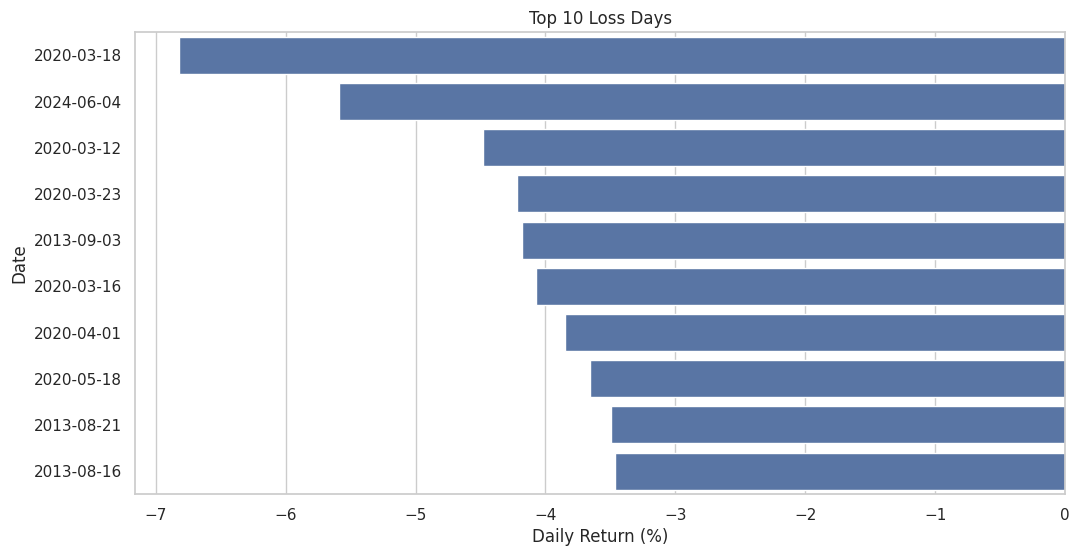

In [ ]:
#Visualization 19 – Top 10 Biggest Loss Days
top_loss=df.nsmallest(10,"Daily Return (%)")

plt.figure(figsize=(12,6))

sns.barplot(
data=top_loss,
x="Daily Return (%)",
y=top_loss["Date"].astype(str)
)

plt.title("Top 10 Loss Days")

plt.show()

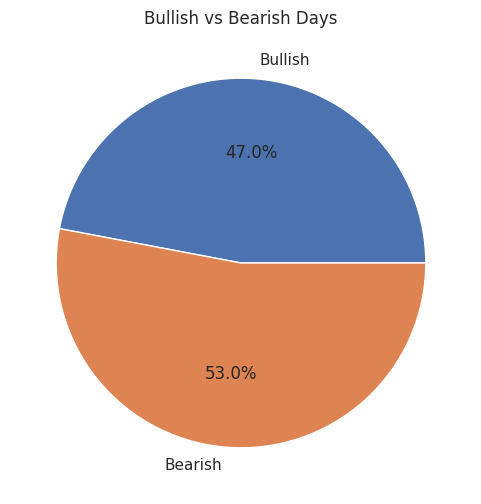

In [ ]:
#Visualization 20 – Bullish vs Bearish Days
counts=[
df["Bullish"].sum(),
df["Bearish"].sum()
]

plt.figure(figsize=(6,6))

plt.pie(
counts,
labels=["Bullish","Bearish"],
autopct="%1.1f%%"
)

plt.title("Bullish vs Bearish Days")

plt.show()

In [ ]:
'''verall Business Insights
The NIFTY 50 shows a long-term upward trend despite temporary market corrections.
Daily returns are centered around zero, indicating normal day-to-day market fluctuations.
Some periods experience high volatility, usually during major market events or economic announcements.
Moving averages help identify short-term, medium-term, and long-term market trends.
Bullish trading sessions slightly outnumber bearish sessions over the long run.
Spikes in trading volume often coincide with significant price movements.
Year-over-year analysis indicates consistent long-term growth in the market.'''